# 03. Deep Learning (modelo global)

En este notebook voy a **definir**, **entrenar** y **evaluar** un modelo de RNN y otro de LSTM sobre toda la serie de temperatura de España (últimos 10 años), sin segmentar por clusters.

---

## 1. Carga y preparación de datos

- **Objetivo**: cargar el pickle con la serie limpia y escalada, y preparar los datos para el modelo.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Cargo el DataFrame preprocesado
ruta_pkl = "../data/temperaturas_limpias_10_años_sin_racha_clusters.pkl"
df = pd.read_pickle(ruta_pkl)

# Índice de fechas y solo la columna objetivo
df["fecha"] = pd.to_datetime(df["fecha"])
df.set_index("fecha", inplace=True)
serie = df["tmed"].values.reshape(-1, 1)

# Escalo la serie entre 0 y 1
escalador = MinMaxScaler()
serie_escalada = escalador.fit_transform(serie)

2. Creación de ventanas deslizantes
¿Por qué? Para que la RNN/LSTM vea siempre los 7 días anteriores y aprenda la dinámica temporal.

In [ ]:
# Función para ventanas deslizantes
def crear_ventanas(datos, tamaño_ventana=7):
    X, y = [], []
    for i in range(len(datos) - tamaño_ventana):
        X.append(datos[i : i + tamaño_ventana, 0])
        y.append(datos[i + tamaño_ventana, 0])
    return np.array(X), np.array(y)

ventana = 7
X, y = crear_ventanas(serie_escalada, ventana)
X = X.reshape(-1, ventana, 1)

# Divido 80% entrenamiento, 20% prueba
n_entreno = int(len(X) * 0.8)
X_train, X_test = X[:n_entreno], X[n_entreno:]
y_train, y_test = y[:n_entreno], y[n_entreno:]


3) Definición y entrenamiento de la RNN


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Construyo el modelo
modelo_rnn = Sequential([
    SimpleRNN(50, input_shape=(ventana, 1)),
    Dense(1)
])
modelo_rnn.compile(optimizer="adam", loss="mse")

# Entreno
historial_rnn = modelo_rnn.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20


/Users/jorgeriverodelosrios/.venvs/global-env/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


45515/45515 ━━━━━━━━━━━━━━━━━━━━ 25s 549us/step - loss: 0.0017 - val_loss: 0.0017
Epoch 2/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 24s 532us/step - loss: 0.0013 - val_loss: 0.0017
Epoch 3/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 25s 552us/step - loss: 0.0013 - val_loss: 0.0016
Epoch 4/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 26s 560us/step - loss: 0.0013 - val_loss: 0.0017
Epoch 5/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 28s 611us/step - loss: 0.0013 - val_loss: 0.0017
Epoch 6/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 25s 539us/step - loss: 0.0013 - val_loss: 0.0017
Epoch 7/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 26s 568us/step - loss: 0.0013 - val_loss: 0.0017
Epoch 8/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 23s 500us/step - loss: 0.0012 - val_loss: 0.0016
Epoch 9/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 23s 495us/step - loss: 0.0012 - val_loss: 0.0017
Epoch 10/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 22s 493us/step - loss: 0.0012 - val_loss: 0.0016
Epoch 11/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 24s 526us/step - loss: 0.0012 - val

4) Evaluación one-step de la RNN
Predicción día a día y métrica MSE/MAE.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

#  One-step: predicción y desescalado
y_pred_escalada = modelo_rnn.predict(X_test).flatten()
y_test_resh     = y_test.reshape(-1, 1)

reales    = escalador.inverse_transform(y_test_resh).flatten()
predichos = escalador.inverse_transform(y_pred_escalada.reshape(-1,1)).flatten()

#  Métricas
mae_one  = mean_absolute_error(reales, predichos)
rmse_one = np.sqrt(mean_squared_error(reales, predichos))

print(f"RNN One-step → MAE: {mae_one:.3f} °C, RMSE: {rmse_one:.3f} °C")

# Gráfico real vs predicho
import plotly.graph_objects as go

fig = go.Figure([
    go.Scatter(x=reales, y=predichos, mode="markers", name="Datos"),
    go.Scatter(x=[reales.min(), reales.max()],
               y=[reales.min(), reales.max()],
               mode="lines", name="y = x",
               line=dict(color="red", dash="dash"))
])
fig.update_layout(
    title="RNN One-step: real vs predicho",
    xaxis_title="Real (°C)",
    yaxis_title="Predicho (°C)"
)
fig.show()



12644/12644 ━━━━━━━━━━━━━━━━━━━━ 3s 265us/step
RNN One-step → MAE: 1.224 °C, RMSE: 1.704 °C


5) Definición y entrenamiento de la LSTM


In [ ]:
from tensorflow.keras.layers import LSTM

# Construyo el modelo LSTM
modelo_lstm = Sequential([
    LSTM(50, input_shape=(ventana, 1)),
    Dense(1)
])
modelo_lstm.compile(optimizer="adam", loss="mse")

# Entreno
historial_lstm = modelo_lstm.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20


/Users/jorgeriverodelosrios/.venvs/global-env/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



45515/45515 ━━━━━━━━━━━━━━━━━━━━ 38s 826us/step - loss: 0.0019 - val_loss: 0.0016
Epoch 2/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 66s 1ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 3/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 73s 2ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 4/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 66s 1ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 5/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 121s 3ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 6/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 74s 2ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 7/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 71s 2ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 8/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 165s 4ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 9/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 68s 1ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 10/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 79s 2ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 11/20
45515/45515 ━━━━━━━━━━━━━━━━━━━━ 50s 1ms/step - loss: 0.0012 - val_loss: 0.0017
Epoc

6) Evaluación one-step de la LSTM


In [ ]:
# Evaluación one-step de la LSTM

from sklearn.metrics import mean_absolute_error, mean_squared_error

#  One-step: predicción y desescalado
y_pred_l_escalada = modelo_lstm.predict(X_test).flatten()
predichos_l = escalador.inverse_transform(
    y_pred_l_escalada.reshape(-1,1)
).flatten()


reales = escalador.inverse_transform(
    y_test.reshape(-1,1)
).flatten()

#  Métricas
mae_lstm_one = mean_absolute_error(reales, predichos_l)
rmse_lstm_one = np.sqrt(mean_squared_error(reales, predichos_l))
print(f"LSTM One-step → MAE: {mae_lstm_one:.3f} °C, RMSE: {rmse_lstm_one:.3f} °C")



12644/12644 ━━━━━━━━━━━━━━━━━━━━ 5s 357us/step
LSTM One-step → MAE: 1.245 °C, RMSE: 1.719 °C


7) Predicción multi-step (7 días)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
RNN Multi-step 7-días → MAE: 2.679 °C, RMSE: 3.003 °C


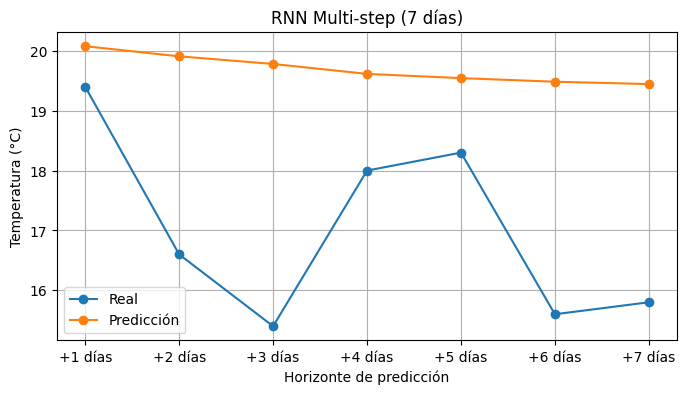

In [ ]:
# Función auxiliar
def predecir_multistep(modelo, ventana_arr, pasos=7):
    preds = []
    vent = ventana_arr.copy()
    for _ in range(pasos):
        siguiente = modelo.predict(vent.reshape(1, -1, 1))[0,0]
        preds.append(siguiente)
        vent = np.append(vent[1:], siguiente)
    return np.array(preds).reshape(-1, 1)

# Aplico sobre la última ventana de test
ultima_ventana = X_test[-1].flatten()
preds7_escalada = predecir_multistep(modelo_rnn, ultima_ventana, pasos=7)
pred7 = escalador.inverse_transform(preds7_escalada).flatten()

#  Real7: extraigo los reales a partir de y_test
n = min(7, len(y_test))
real7 = escalador.inverse_transform(y_test[:n].reshape(-1,1)).flatten()

#  Métricas multi-step
mae_multistep = mean_absolute_error(real7, pred7[:n])
rmse_multistep = np.sqrt(mean_squared_error(real7, pred7[:n]))
print(f"RNN Multi-step 7-días → MAE: {mae_multistep:.3f} °C, RMSE: {rmse_multistep:.3f} °C")

#  Gráfico horizonte de 1-7
import matplotlib.pyplot as plt
horizonte = list(range(1, n+1))
plt.figure(figsize=(8,4))
plt.plot(horizonte, real7, marker='o', label='Real')
plt.plot(horizonte, pred7[:n], marker='o', label='Predicción')
plt.xticks(horizonte, [f"+{d} días" for d in horizonte])
plt.title("RNN Multi-step (7 días)")
plt.xlabel("Horizonte de predicción")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(True)
plt.show()
